In [1]:
import sys
import os

# Remonte d'un niveau : notebooks/ → Machine_Learning/
sys.path.insert(0, os.path.abspath(".."))

print(sys.path[0])  # Doit afficher le chemin vers Machine_Learning/

c:\Users\cuadr\Desktop\Projet Jedha Groupe\Machine_Learning


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.build_dataset      import build_ml_dataset
from src.preprocessing_ml   import prepare_features
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling  import SMOTE

print("✅ Imports OK")

✅ Imports OK


In [3]:
df = build_ml_dataset()
print(df.shape)
df.head(3)

🔍 Query : SELECT "Num_Acc", "id_vehicule", "gravite", "sexe", "tranche_age", "categorie_usager_label", "motif_trajet_label", "equipement_secu_1_label" FROM publ
✅ view_usager : 506,886 lignes × 8 colonnes
🔍 Query : SELECT "Num_Acc", "luminosite_label", "agglomeration_label", "intersection_label", "meteo_label", "type_collision_label", "tranche_horaire_label", "ca
✅ view_global_caract_lieux : 221,044 lignes × 11 colonnes
🔍 Query : SELECT "Num_Acc", "vacances_scolaires_flag" FROM public."view_caract" 
✅ view_caract : 221,044 lignes × 2 colonnes
🔍 Query : SELECT "Num_Acc", "id_vehicule", "categorie_vehicule_label", "motorisation_label" FROM public."view_vehicules" 
✅ view_vehicules : 378,071 lignes × 4 colonnes

📊 Dataset final : 506,886 lignes × 21 colonnes
Répartition gravite :
gravite
1.0    215092
4.0    201026
3.0     76750
2.0     13599
Name: count, dtype: int64

(506886, 21)


,Num_Acc,id_vehicule,gravite,sexe,tranche_age,categorie_usager_label,motif_trajet_label,equipement_secu_1_label,luminosite_label,agglomeration_label,...,meteo_label,type_collision_label,tranche_horaire_label,categorie_route_label,etat_surface_label,infrastucture_label,annee_source,vacances_scolaires_flag,categorie_vehicule_label,motorisation_label
0,202100000598,200 632,1.0,1.0,46-64 ans,Conducteur,Non renseigné,Ceinture,Nuit avec éclairage public allumé,En agglomération,...,Pluie légère,Deux véhicules – par le coté,06h - 08h,Voie Communales,Mouillée,Aucun,2021,0,Véhicules Légers (VL),Hydrocarbures
1,202100000090,201 589,1.0,1.0,46-64 ans,Conducteur,Promenade – loisirs,Ceinture,Plein jour,En agglomération,...,Normale,Autre collision,12h - 14h,Route Départementale,Normale,Carrefour aménagé,2021,0,Véhicules Légers (VL),Hydrocarbures
2,202100000091,201 586,1.0,1.0,26-45 ans,Conducteur,Non renseigné,Ceinture,Plein jour,En agglomération,...,Normale,Deux véhicules – par le coté,16h - 18h,Route Départementale,Normale,Aucun,2021,0,Véhicules Légers (VL),Hydrocarbures


In [4]:
X, y = prepare_features(df)
print("Classes :", y.value_counts().to_dict())

✅ X : (506467, 18) | y (mortels) : 13,599 / 506,467 (2.69%)
Classes : {0: 492868, 1: 13599}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=3, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Après SMOTE → {y_train_res.value_counts().to_dict()}")

Après SMOTE → {0: 394294, 1: 394294}


In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
print("✅ Modèle entraîné")

✅ Modèle entraîné


              precision    recall  f1-score   support

  Non mortel       0.99      0.84      0.91     98574
      Mortel       0.09      0.58      0.16      2720

    accuracy                           0.84    101294
   macro avg       0.54      0.71      0.53    101294
weighted avg       0.96      0.84      0.89    101294



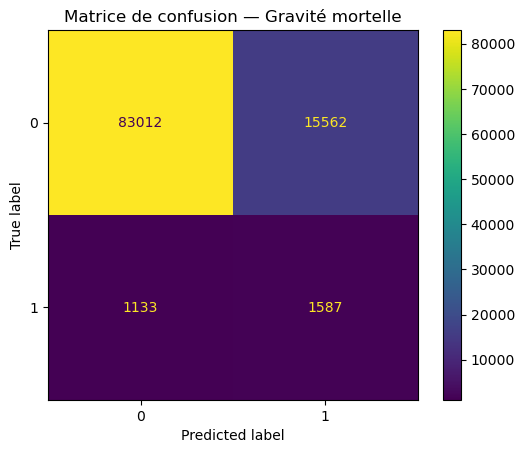

In [7]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Non mortel", "Mortel"]))

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Matrice de confusion — Gravité mortelle")
plt.show()

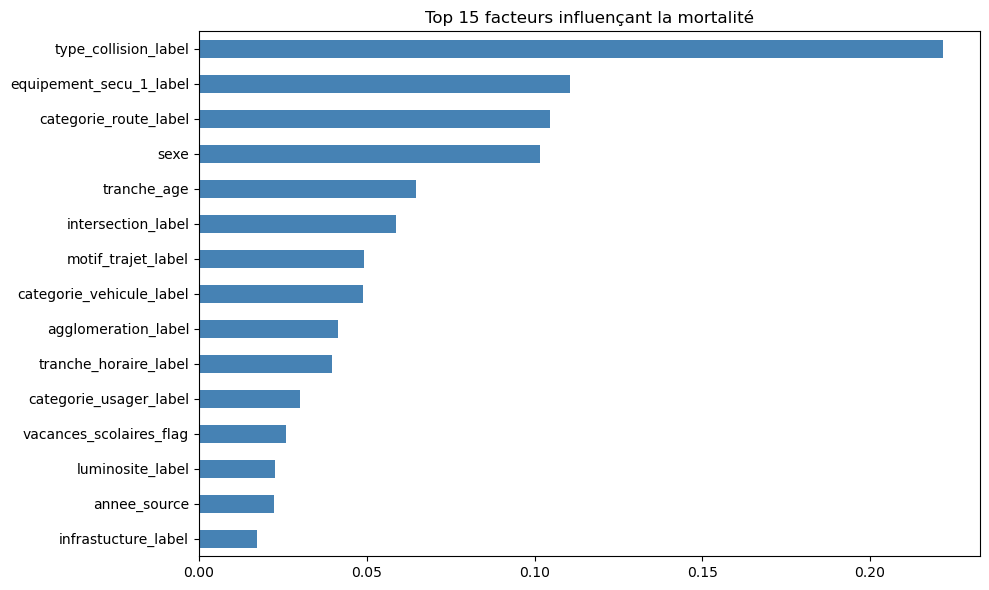

In [8]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns) \
             .sort_values(ascending=False)

feat_imp.head(15).plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Top 15 facteurs influençant la mortalité")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()